Section 1 — Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

Section 2 — Load Data

In [3]:
DATA_PATH = Path("../data/demographics.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,pid,responses,logins,first_login,last_login,country,age,gender,n_demographics
0,p1,77.0,24,2022-08-18 22:53:05,2023-01-31 23:16:34,USA,22.0,Male,1
1,p10,340.0,16,2023-02-18 03:02:03,2023-03-04 12:33:53,Czech Republic,28.0,Female,1
2,p100,1.0,1,2022-09-07 16:06:20,NaN,UK,20.0,Transgender,1
3,p1000,1.0,1,2022-08-23 14:43:12,NaN,USA,18.0,Female,1
4,p10000,7.0,2,2022-09-03 23:50:01,2022-09-16 23:31:56,USA,44.0,Female,1


Section 3 — Dataset Overview

In [4]:
print(df.shape)

df.info()

df.describe(include="all")

(11080, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11080 entries, 0 to 11079
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             11080 non-null  object 
 1   responses       10042 non-null  float64
 2   logins          11080 non-null  int64  
 3   first_login     11080 non-null  object 
 4   last_login      8248 non-null   object 
 5   country         10670 non-null  object 
 6   age             10964 non-null  float64
 7   gender          11018 non-null  object 
 8   n_demographics  11080 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 779.2+ KB


,pid,responses,logins,first_login,last_login,country,age,gender,n_demographics
count,11080,10042.000000,11080.000000,11080,8248,10670,10964.000000,11018,11080.000000
unique,11080,NaN,NaN,11038,8241,39,NaN,60,NaN
top,p1,NaN,NaN,2023-02-01 02:46:01,2023-02-02 03:12:56,USA,NaN,Male,NaN
freq,1,NaN,NaN,2,2,5978,NaN,6086,NaN
mean,NaN,72.025991,10.198917,NaN,NaN,NaN,28.251186,NaN,1.026354
std,NaN,103.816652,16.006891,NaN,NaN,NaN,8.813566,NaN,0.238898
min,NaN,1.000000,1.000000,NaN,NaN,NaN,18.000000,NaN,1.000000
25%,NaN,8.000000,1.000000,NaN,NaN,NaN,21.000000,NaN,1.000000
50%,NaN,44.000000,5.000000,NaN,NaN,NaN,27.000000,NaN,1.000000
75%,NaN,82.000000,12.000000,NaN,NaN,NaN,33.000000,NaN,1.000000


Section 4 — Missing Values

In [5]:
missing = (
    df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

last_login        2832
responses         1038
country            410
age                116
gender              62
pid                  0
logins               0
first_login          0
n_demographics       0
dtype: int64

In [6]:
missing_percentage = (
    missing / len(df)
) * 100

missing_percentage

last_login        25.559567
responses          9.368231
country            3.700361
age                1.046931
gender             0.559567
pid                0.000000
logins             0.000000
first_login        0.000000
n_demographics     0.000000
dtype: float64

Section 5 — Age Distribution

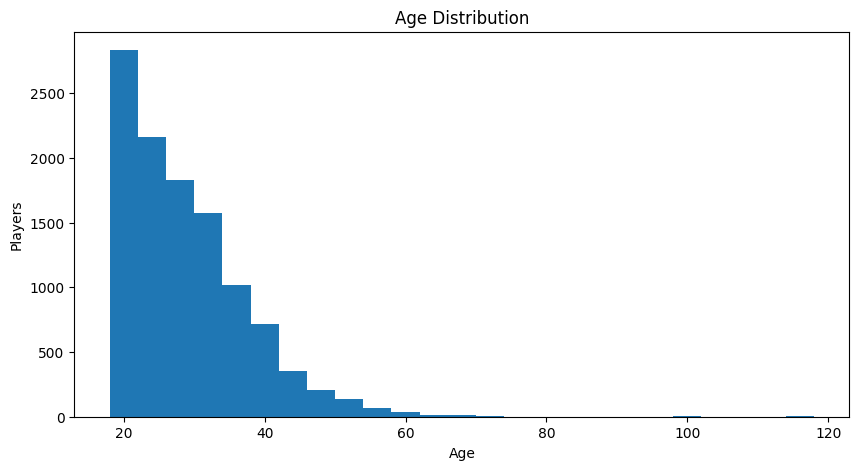

In [7]:
plt.figure(figsize=(10,5))

plt.hist(df["age"].dropna(), bins=25)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Players")

plt.show()

It seems my assumption is becoming true as I could see the max comes under an outlier.

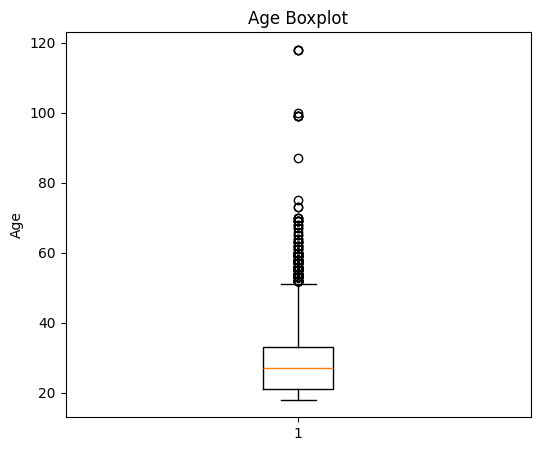

In [8]:
plt.figure(figsize=(6,5))

plt.boxplot(df["age"].dropna())

plt.title("Age Boxplot")

plt.ylabel("Age")

plt.show()

I see the most of the population falls between 18-50.

Section 7 — Country Distribution

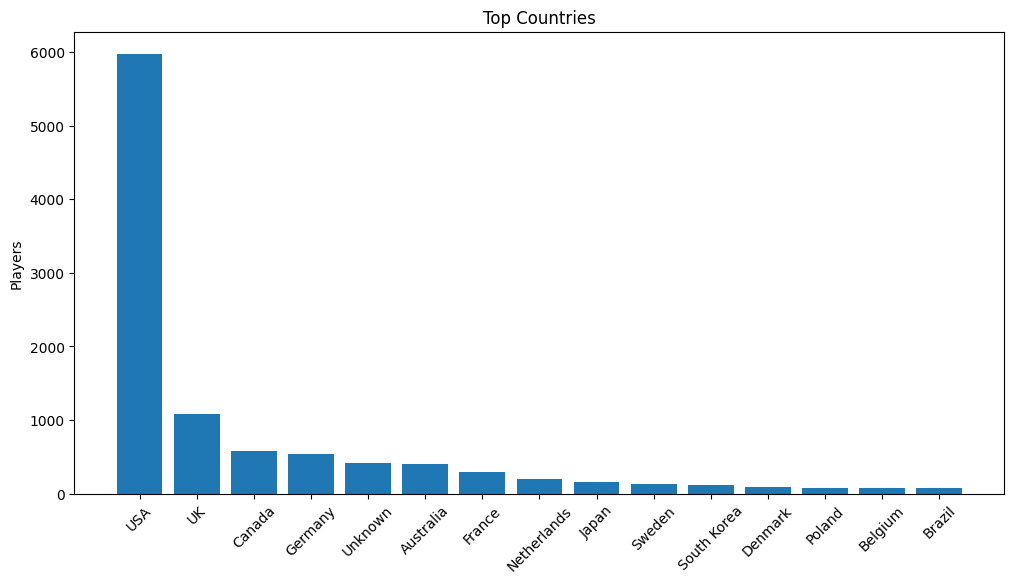

In [9]:
country_counts = (
    df["country"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.xticks(rotation=45)

plt.title("Top Countries")

plt.ylabel("Players")

plt.show()

### Observation

#### The majority of participants are located in the United States.

### Evidence

#### Country frequency distribution.

### Interpretation

#### The study population is geographically imbalanced and may not represent the global player population.

## Research Impact

#### Country may act as a confounding variable during statistical analysis and should be interpreted with caution.

Section 8 — Gender Distribution

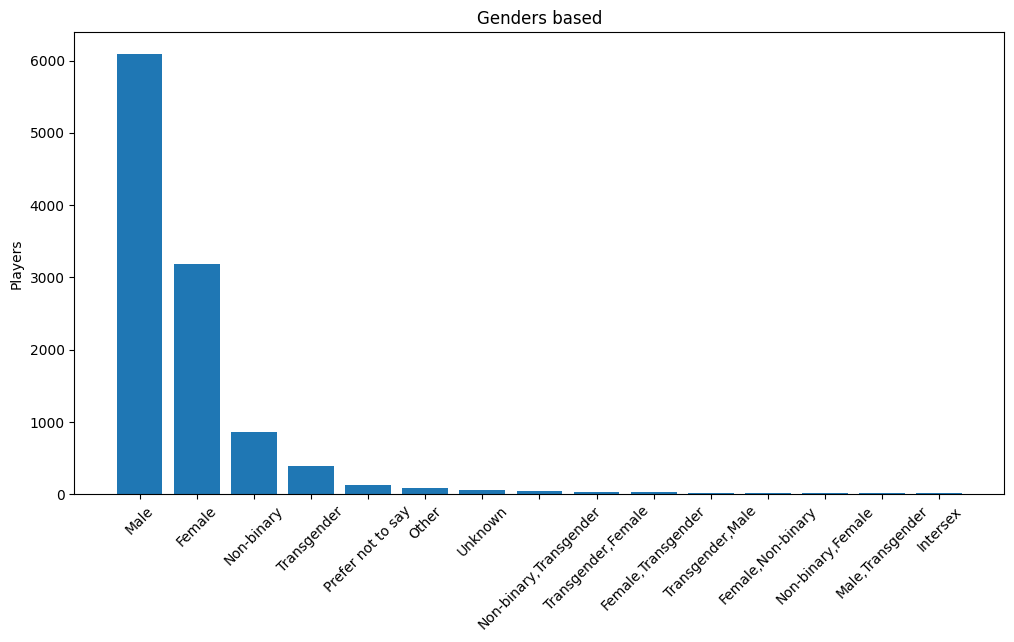

In [10]:
gender_counts = (
    df["gender"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.xticks(rotation=45)

plt.title("Genders based")

plt.ylabel("Players")

plt.show()

Male is the highest portion and the next is Female. Non-binary and Transgender can be considered at least. 

### Observation

#### The majority of participants are Male and Female

### Evidence

#### Gender frequency distribution.

### Interpretation

#### The study population is gender imbalanced.

## Research Impact

#### Gender may act as a confounding variable during statistical analysis and should be interpreted with caution.

Section 9 — Login Distribution

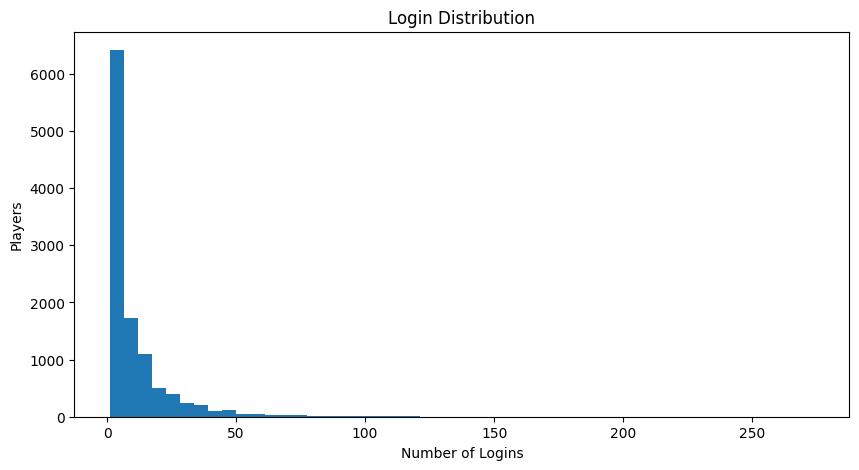

In [15]:
plt.figure(figsize=(10,5))

plt.hist(
    df["logins"],
    bins=50
)

plt.title("Login Distribution")

plt.xlabel("Number of Logins")

plt.ylabel("Players")

plt.show()

Section 10 — Correlation

In [16]:
numeric = df.select_dtypes(include=np.number)

numeric.corr()

,responses,logins,age,n_demographics
responses,1.000000,0.826063,0.248413,0.150605
logins,0.826063,1.000000,0.186448,0.178607
age,0.248413,0.186448,1.000000,0.028321
n_demographics,0.150605,0.178607,0.028321,1.000000


I can see there is a good correlation between the logins and responses. 'age' is the next highest which means there is some correlation with the age and logins which is around 0.24 but it also tells who has sent more responses. May be they play online more etc.

Section 11 — Derived Feature

In [17]:
df["study_duration_days"] = (
    pd.to_datetime(df["last_login"])
    -
    pd.to_datetime(df["first_login"])
).dt.days

Text(0.5, 1.0, 'Study Duration')

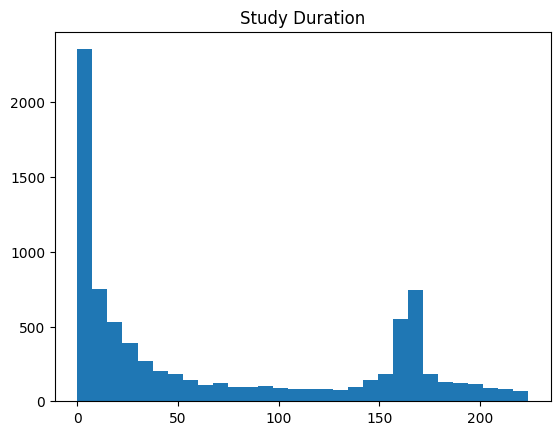

In [18]:
plt.hist(
    df["study_duration_days"].dropna(),
    bins=30
)

plt.title("Study Duration")

This looks something interesting. It tells us that players play the game initially and there is a decline with the number of days. There is a sudden increment with the player count between 150 -200 and it started declining again.